# Singular Value Decomposition (SVD): image compression and denoising

In this notebook we study two closely related applications of the singular value decomposition (SVD) using a grayscale image:

1. **Image compression**: approximate the image by a low-rank matrix and store only the most important singular directions.
2. **Image denoising**: add Gaussian noise to the image and then use a truncated SVD to recover a cleaner approximation.

These two tasks are based on the same idea: many natural images can be approximated well by keeping only the dominant singular values and singular vectors. In compression, this reduces storage. In denoising, it suppresses weak components that are often associated with noise.


## Learning goals

By the end of this notebook, you should be able to:

- compute the economy SVD of an image matrix,
- build low-rank approximations of an image,
- interpret singular values as a hierarchy of importance,
- measure reconstruction quality with Frobenius-norm errors,
- estimate storage savings from truncated SVD,
- explain how truncated SVD can remove part of the noise in an image,
- discuss the trade-off between compression, denoising, and image quality.


## 1. Load and visualize the image

We will work with a grayscale image stored as a matrix $X\in\mathbb{R}^{n\times m}$.

Image shape: (1536, 1024)
Pixel range: [0.0, 238.0]


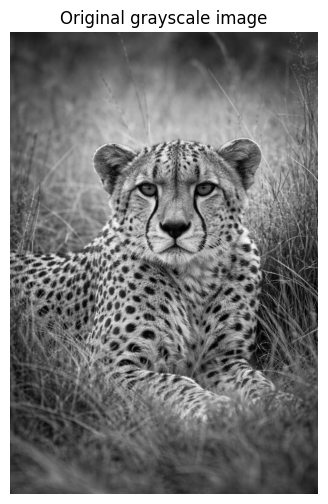

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.figsize"] = (6, 6)

#image_path = "data/Image_Owl.png"
image_path = "data/Image_Cheetah.png"
X = np.array(Image.open(image_path).convert("L"), dtype=float)
n, m = X.shape

print(f"Image shape: {X.shape}")
print(f"Pixel range: [{X.min():.1f}, {X.max():.1f}]")

plt.imshow(X, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

## 2. Full SVD and economy SVD

Recall that the full SVD of the image matrix is
$$
X = U\Sigma V^T.
$$
If $X\in\mathbb{R}^{n\times m}$ with $n\ge m$, the **economy SVD** keeps only the nonzero rectangular part and is often more efficient in practice.

In this notebook we will use both forms:
- the **full SVD** to inspect the matrix shapes,
- the **economy SVD** to build low-rank approximations efficiently.

In [3]:
U_full, s_full, VT_full = np.linalg.svd(X, full_matrices=True)
U, s, VT = np.linalg.svd(X, full_matrices=False)

print("Full SVD shapes:", U_full.shape, s_full.shape, VT_full.shape)
print("Economy SVD shapes:", U.shape, s.shape, VT.shape)

Full SVD shapes: (1536, 1536) (1024,) (1024, 1024)
Economy SVD shapes: (1536, 1024) (1024,) (1024, 1024)


## 3. Singular values and cumulative information

The singular values are ordered from largest to smallest. A rapid decay indicates that only a few dominant patterns are needed to represent the image accurately.

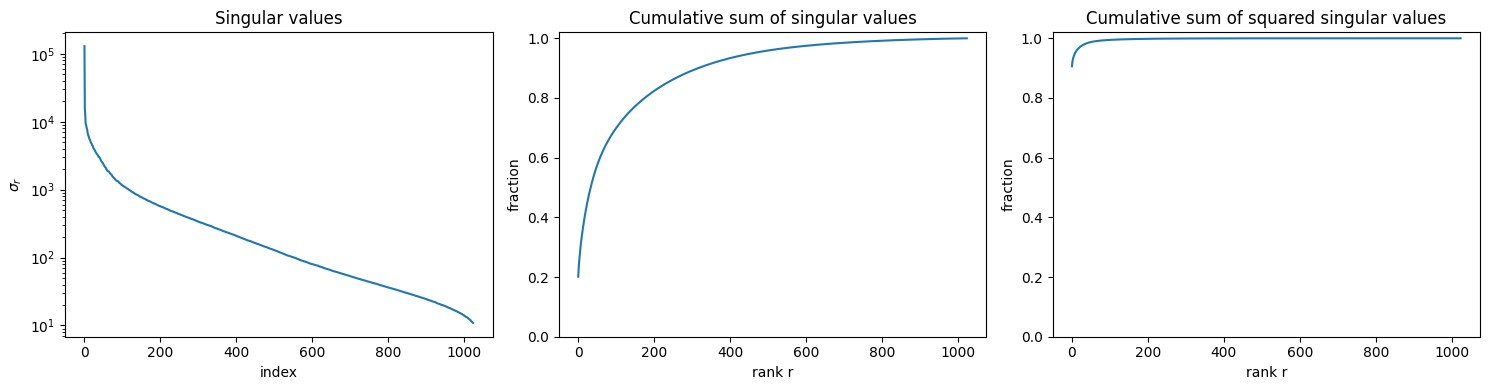

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(s)
axes[0].set_title("Singular values")
axes[0].set_xlabel("index")
axes[0].set_ylabel(r"$\sigma_r$")

axes[1].plot(np.cumsum(s) / np.sum(s))
axes[1].set_title("Cumulative sum of singular values")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("fraction")
axes[1].set_ylim(0, 1.02)

axes[2].plot(np.cumsum(s**2) / np.sum(s**2))
axes[2].set_title("Cumulative sum of squared singular values")
axes[2].set_xlabel("rank r")
axes[2].set_ylabel("fraction")
axes[2].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

## 4. Low-rank image reconstruction

The reconstruction quality usually improves rapidly with rank, while the storage requirement grows only linearly in $r$.

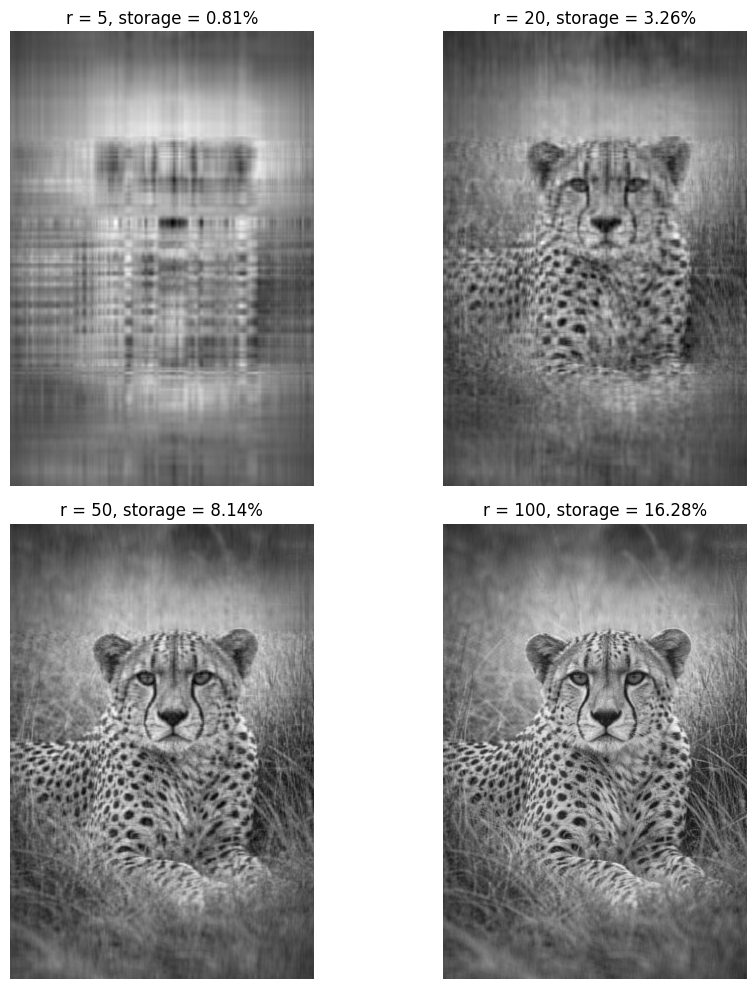

In [137]:
r_values = [5, 20, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, r in zip(axes.ravel(), r_values):
    Ur = U[:, :r]
    Sr = np.diag(s[:r])
    VTr = VT[:r, :]
    Xr = Ur @ Sr @ VTr
    storage_fraction = (n * r + r + m * r) / (n * m)

    ax.imshow(Xr, cmap="gray")
    ax.set_title(f"r = {r}, storage = {100*storage_fraction:.2f}%")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. $U_r^T U_r$ versus $U_r U_r^T$

The first product is the identity because the columns of $U_r$ are orthonormal. The second product is instead the orthogonal projector onto the rank-$r$ column space spanned by those singular vectors.

In [24]:
r_test = 40
Ur = U[:, :r_test]

left_product = Ur.T @ Ur
right_product = Ur @ Ur.T

print("||U_r^T U_r - I_r||_F =", np.linalg.norm(left_product - np.eye(r_test), ord='fro'))
print("||U_r U_r^T - I_n||_F =", np.linalg.norm(right_product - np.eye(n), ord='fro'))

||U_r^T U_r - I_r||_F = 1.652451082965433e-14
||U_r U_r^T - I_n||_F = 38.67815921162743


## 6. Reconstruction error and captured variance

The Eckart--Young theorem tells us that the truncated SVD gives the best rank-$r$ approximation in the Frobenius norm. Because
$$
\|X\|_F^2 = \sum_k \sigma_k^2,
$$
the squared relative error is directly tied to the tail of the singular-value spectrum.

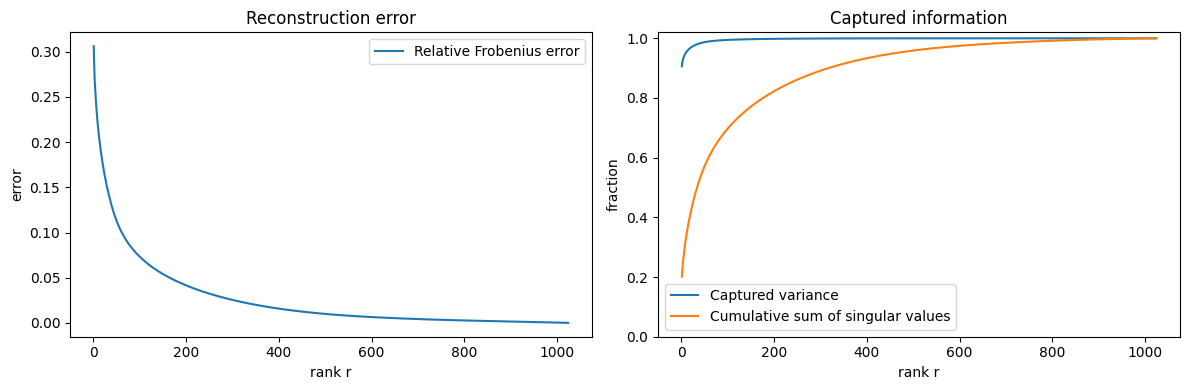

In [25]:
ranks = np.arange(1, len(s) + 1)

cumulative_sigma = np.cumsum(s) / np.sum(s)
cumulative_sigma_sq = np.cumsum(s**2) / np.sum(s**2)
missing_variance = 1 - cumulative_sigma_sq
rel_fro_error = np.sqrt(missing_variance)
captured_variance = cumulative_sigma_sq

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ranks, rel_fro_error, label="Relative Frobenius error")
axes[0].set_title("Reconstruction error")
axes[0].set_xlabel("rank r")
axes[0].set_ylabel("error")
axes[0].legend()

axes[1].plot(ranks, captured_variance, label="Captured variance")
axes[1].plot(ranks, cumulative_sigma, label="Cumulative sum of singular values")
axes[1].set_title("Captured information")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("fraction")
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

In [142]:
r_var_99 = np.argmax(captured_variance >= 0.99) + 1
r_fro_99 = np.argmax((1 - rel_fro_error) >= 0.99) + 1
r_sigma_99 = np.argmax(cumulative_sigma >= 0.99) + 1

print("Rank for 99% captured variance:", r_var_99)
print("Rank for 99% of 1 - relative Frobenius error:", r_fro_99)
print("Rank for 99% cumulative singular-value sum:", r_sigma_99)

Rank for 99% captured variance: 62
Rank for 99% of 1 - relative Frobenius error: 499
Rank for 99% cumulative singular-value sum: 769


## 7. Add Gaussian noise to the image

We now extend the notebook from **compression** to **denoising**.

Starting from the clean grayscale image, we add Gaussian noise to obtain a corrupted image. Then we compute the SVD of the noisy image and compare two truncation strategies:

- an **SVD hard threshold** based on the known noise level,
- a **90% cumulative-sum cutoff**.

This lets us compare visual quality, truncation rank, and reconstruction error.


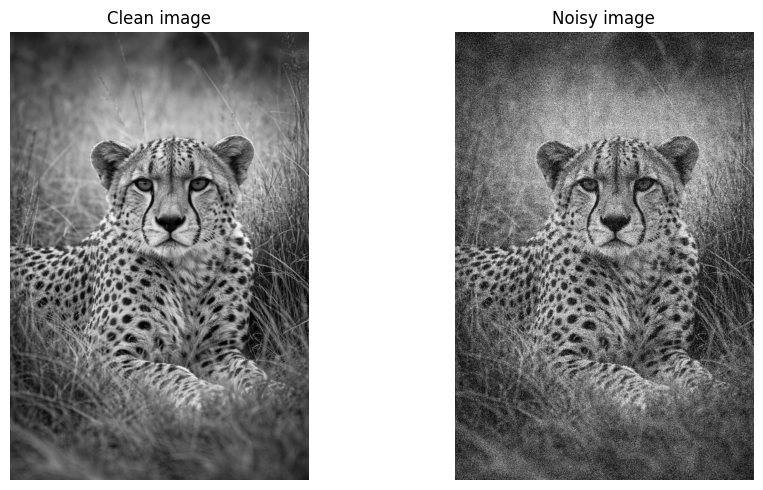

In [27]:
# Create a noisy version of the image
np.random.seed(7)

noise_std = 50.0
X_noisy = X + noise_std * np.random.randn(*X.shape)
X_noisy = np.clip(X_noisy, 0, 255)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(X, cmap="gray")
axes[0].set_title("Clean image")
axes[0].axis("off")

axes[1].imshow(X_noisy, cmap="gray")
axes[1].set_title("Noisy image")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 8. Compute the SVD of the noisy image

Let
$$
X_{\text{noisy}} = U\Sigma V^T.
$$

We will inspect the singular values and then choose truncation ranks in two different ways.


In [29]:
# Economy SVD of the noisy image
U_noisy, s_noisy, VT_noisy = np.linalg.svd(X_noisy, full_matrices=False)


## 9. Choose truncation ranks

We now reproduce the two truncation ideas from the book:

1. **Hard threshold** based on the known Gaussian noise level.
2. **90% cumulative-sum cutoff**.

Because the image matrix is rectangular, we use the rectangular hard-threshold formula
$$
\tau = \lambda(\beta)\sqrt{n}\,\sigma,
$$
where $\beta$ is the aspect ratio and $\sigma$ is the noise standard deviation.


In [31]:
# Hard threshold and 90% cumulative-sum cutoff
n_rows, n_cols = X_noisy.shape
beta = min(n_rows, n_cols) / max(n_rows, n_cols)

lambda_beta = np.sqrt(
    2 * (beta + 1)
    + (8 * beta) / ((beta + 1) + np.sqrt(beta**2 + 14 * beta + 1))
)

cutoff = lambda_beta * np.sqrt(max(n_rows, n_cols)) * noise_std

r_hard = int(np.sum(s_noisy > cutoff))
cumulative_sum = np.cumsum(s_noisy) / np.sum(s_noisy)
r90 = int(np.searchsorted(cumulative_sum, 0.90) + 1)

print(f"hard-threshold rank = {r_hard}")
print(f"90% cumulative-sum rank = {r90}")
print(f"hard threshold value = {cutoff:.2f}")


hard-threshold rank = 31
90% cumulative-sum rank = 755
hard threshold value = 4115.54


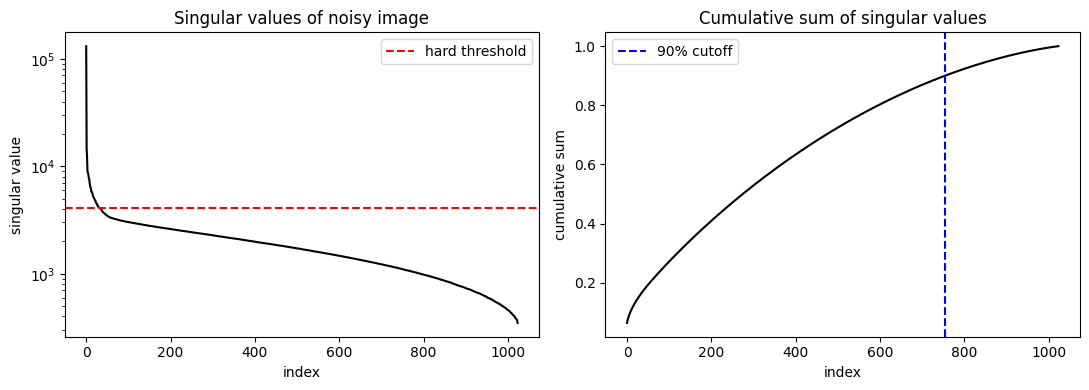

In [32]:
# Singular values and cumulative sum
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(s_noisy, "k")
axes[0].axhline(cutoff, color="r", linestyle="--", label="hard threshold")
axes[0].set_title("Singular values of noisy image")
axes[0].set_xlabel("index")
axes[0].set_ylabel("singular value")
axes[0].legend()

axes[1].plot(cumulative_sum, "k")
axes[1].axvline(r90 - 1, color="b", linestyle="--", label="90% cutoff")
axes[1].set_title("Cumulative sum of singular values")
axes[1].set_xlabel("index")
axes[1].set_ylabel("cumulative sum")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Reconstruct denoised images

Using the two ranks above, build two low-rank approximations of the noisy image:

- one from the **hard threshold**,
- one from the **90% cumulative-sum cutoff**.

Compare them with the clean and noisy images.


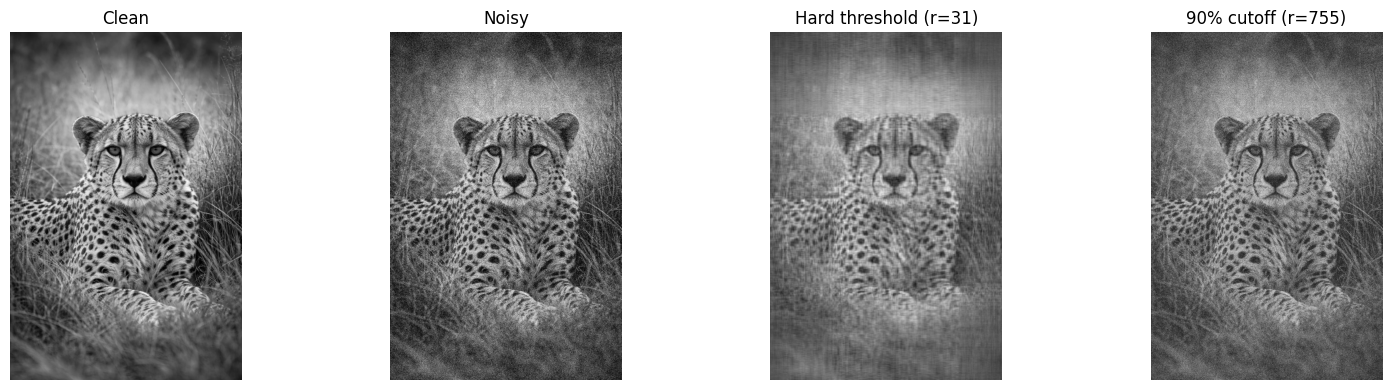

In [33]:
# Denoised reconstructions
X_hard = U_noisy[:, :r_hard] @ np.diag(s_noisy[:r_hard]) @ VT_noisy[:r_hard, :]
X_90 = U_noisy[:, :r90] @ np.diag(s_noisy[:r90]) @ VT_noisy[:r90, :]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(X, cmap="gray")
axes[0].set_title("Clean")
axes[0].axis("off")

axes[1].imshow(X_noisy, cmap="gray")
axes[1].set_title("Noisy")
axes[1].axis("off")

axes[2].imshow(X_hard, cmap="gray")
axes[2].set_title(f"Hard threshold (r={r_hard})")
axes[2].axis("off")

axes[3].imshow(X_90, cmap="gray")
axes[3].set_title(f"90% cutoff (r={r90})")
axes[3].axis("off")

plt.tight_layout()
plt.show()


## 11. Compare the denoising results quantitatively

We compare the relative Frobenius errors with respect to the clean image:
$$
\frac{\|X-X_{\text{approx}}\|_F}{\|X\|_F}.
$$

This helps us check whether the denoised images are genuinely closer to the clean image than the noisy one.


In [34]:
# Relative Frobenius errors
err_noisy = np.linalg.norm(X - X_noisy, ord="fro") / np.linalg.norm(X, ord="fro")
err_hard = np.linalg.norm(X - X_hard, ord="fro") / np.linalg.norm(X, ord="fro")
err_90 = np.linalg.norm(X - X_90, ord="fro") / np.linalg.norm(X, ord="fro")

print(f"Noisy image error:            {err_noisy:.4f}")
print(f"Hard-threshold SVD error:     {err_hard:.4f}")
print(f"90% cumulative-sum error:     {err_90:.4f}")


Noisy image error:            0.4336
Hard-threshold SVD error:     0.1837
90% cumulative-sum error:     0.4242


## Final discussion

1. **Why do the first singular values capture most of the visible structure of the image?**  
   Because natural images often have strong correlations, and the leading singular directions represent the dominant large-scale patterns and contrasts.

2. **How does increasing the truncation rank improve the compressed image?**  
   A larger rank keeps more singular components, so the reconstruction includes more detail and looks closer to the original image.

3. **Why does truncated SVD reduce storage requirements?**  
   Instead of storing all pixel values, we store only the first $r$ columns of $U$, the first $r$ singular values, and the first $r$ rows of $V^T$.

4. **Why can truncated SVD remove part of the Gaussian noise?**  
   Because much of the structured image content is concentrated in the leading singular values, while noise is spread across many weaker singular directions.

5. **What is the idea behind the SVD hard threshold?**  
   It keeps only singular values that are sufficiently larger than the level expected from Gaussian noise, so it aims to separate dominant signal from noise-dominated components.

6. **Why can the 90% cumulative-sum cutoff keep more noise than the hard threshold?**  
   Because it is based only on retaining a fixed fraction of the total singular-value mass, not on an explicit noise model. As a result, it may keep many small singular values that still contain noise.

7. **How are compression and denoising based on the same low-rank idea?**  
   In both cases we keep the dominant singular components and discard weaker ones. For compression this saves storage, and for denoising it suppresses unwanted variation.
